In [3]:
%load_ext autoreload
%autoreload 2

In [4]:
from moc.configs.config import get_config
from moc.utils.run_config import RunConfig
# from moc.models.mqf2.lightning_module import MQF2LightningModule
from moc.models.mixture.mixture_model2 import MixtureLightningModule
from moc.models.gaussian.gaussian import GaussianLightningModule
from moc.models.trainers.lightning_trainer import get_lightning_trainer
from moc.datamodules.real_datamodule import RealDataModule
import numpy as np
import matplotlib.pyplot as plt
from moc.metrics.distribution_metrics import pce
import torch
import pickle
import wandb
import os

os.environ["CUDA_VISIBLE_DEVICES"] = "6"

In [5]:
plt.style.use('seaborn-v0_8')

In [6]:
with open("pkl-files/pce_across_32datasets_mixnll_marginal.pkl", "rb") as f:
    marginal = pickle.load(f)
with open("pkl-files/pce_across_32datasets_mixnll_mean.pkl", "rb") as f:
    mean = pickle.load(f)
with open("pkl-files/pce_across_32datasets_mixnll_variance.pkl", "rb") as f:
    variance = pickle.load(f)
with open("pkl-files/pce_across_32datasets_mixnll_dependency.pkl", "rb") as f:
    dependency = pickle.load(f)
with open("pkl-files/pce_across_32datasets_mixnll_pca.pkl", "rb") as f:
    pca = pickle.load(f)
with open("pkl-files/pce_across_32datasets_mixnll_density.pkl", "rb") as f:
    hdr = pickle.load(f)

In [ ]:
for index, (dataset, stat) in enumerate(hdr.items()):
    avg_pce, std_err = stat
    print(f"Dataset {index}: {dataset}, PCE: {avg_pce:.3f} ({std_err:.3f})")

In [6]:
config = get_config()
config.device = 'cuda'
torch.manual_seed(42)

In [ ]:
seeds = [0, 42, 866, 12, 4]
prerank = 'pca'
data_group, data_name = 'mulan', 'oes10'
cdf_over_seed, pce_over_seeds = [], []
for seed in seeds:
    print(f"working on seed {seed}")
    rc = RunConfig(config, data_group, data_name, seed = seed)
    datamodule = RealDataModule(rc, seed=seed, num_workers = 8)
    p, q = datamodule.input_dim, datamodule.output_dim
    # model = GaussianLightningModule(p, q, lambda_reg = 1, reg_type = 'pce-kde', prerank = 'density')
    model = MixtureLightningModule(p, q, prerank = prerank)
    #model = MQF2LightningModule(p, q)
    trainer = get_lightning_trainer(rc)
    trainer.fit(model, datamodule)
    # wandb.finish()
    model.to(config.device)
    # pce_over_seeds = np.array(pce_over_seeds)
    model.eval()
    pces, cdfs = [], []
    if prerank == 'pca':
        weights = []
    with torch.no_grad():
        for x, y in datamodule.val_dataloader():
            x = x.to(config.device)
            y = y.to(config.device)
            dist = model.predict(x)
            pce_values, cdf_values, _ = pce(dist, y, n_samples = 100, prerank = prerank, setup='real', mode = 'test')
            # cdf = reliability_plots(dist, y, n_samples = 100, prerank = 'marginal', setup = 'real')
            pces.append(pce_values)
            cdfs.append(cdf_values)
            if prerank == 'pca':
                explained_var = torch.from_numpy(_).to(pce_values.device)
                weights.append(explained_var)
    pce_total = torch.stack(pces).mean(dim=0)
    cdfs_total = torch.stack(cdfs).mean(dim=0)
    if prerank == 'pca':
        weights_total = torch.stack(weights).mean(dim=0)
        pce_total = torch.sum(pce_total * weights_total)
    elif prerank =='marginal':
        pce_total = pce_total.mean(dim=0)
    # explained_var = np.stack(explained_var).mean(axis=0)
    pce_over_seeds.append(pce_total.cpu().numpy())
    cdf_over_seed.append(cdfs_total.cpu().numpy())
pce_over_seeds = np.stack(pce_over_seeds)
cdf_over_seed = np.stack(cdf_over_seed)

/home/ubuntu/anaconda3/envs/multicalibration/lib/python3.12/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/ubuntu/anaconda3/envs/multicalibration/lib/pyt ...
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/ubuntu/anaconda3/envs/multicalibration/lib/python3.12/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:654: Checkpoint directory /mnt/default/elnura_workspace/Multivariate-recalibration/Multicalibration/Projected_PIT_calibration/logs/2025-05-23/11-08-42/mulan/oes10/None/0/checkpoints exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [6]


working on seed 0


RuntimeError: Expected all tensors to be on the same device, but found at least two devices, cuda:0 and cpu!

In [15]:
cdf_over_seed.shape

(5, 1, 100)

In [16]:
alphas = np.linspace(0, 1, 100)

In [17]:
pce_over_seeds

array([[0.22325   ],
       [0.05398485],
       [0.0549495 ],
       [0.21225   ],
       [0.03457576]], dtype=float32)

In [18]:
cdf_over_seed = np.squeeze(cdf_over_seed, axis = 1)

In [12]:
plt.rcParams.update({
    'axes.titlesize': 12,
    'axes.labelsize': 12,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12
})

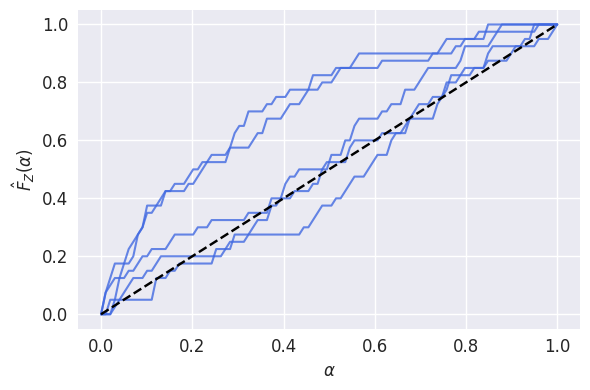

In [19]:
colors = [
    'royalblue',
    'darkorange',
    'seagreen',
    'crimson',
    'goldenrod',
    'mediumorchid',
    'deepskyblue',
    'saddlebrown'
]
plt.figure(figsize=(6, 4))
for s in range(len(seeds)):
    plt.plot(alphas, cdf_over_seed[s], color = 'royalblue', 
            #  label=f"d = {d+1}", 
             lw = 1.5, alpha = 0.8)
plt.plot(alphas, alphas, linestyle='--', color='black')
plt.xlabel(r"$\alpha$")
plt.ylabel(r"$\hat{F}_Z(\alpha)$")
# plt.legend(loc='upper left')
# plt.title(f"{data_name}")
plt.grid(True)
plt.tight_layout()
plt.savefig(f"figures/rel_plot_{prerank}_{data_name}.png", dpi=300)
plt.show()

In [13]:
pce_total.shape

torch.Size([8])

In [15]:
pce_total.mean()

tensor(0.0482, device='cuda:0')

In [186]:
pce_over_seed.mean()

np.float64(0.04180807828822214)

In [195]:
weights = np.stack(weights).mean(axis=0)
np.sum(pce_over_seed*weights)

np.float64(0.04588062526477785)

In [7]:
average_pce = pce_over_seeds[0].mean(axis=0)
stderr_pce = pce_over_seeds[0].std(axis=0, ddof = 1) / np.sqrt(5)
print(average_pce)
print(stderr_pce)

[0.523662   0.52711087 0.52279346 0.52475633]
[0.3012626  0.29908134 0.30181192 0.30057049]


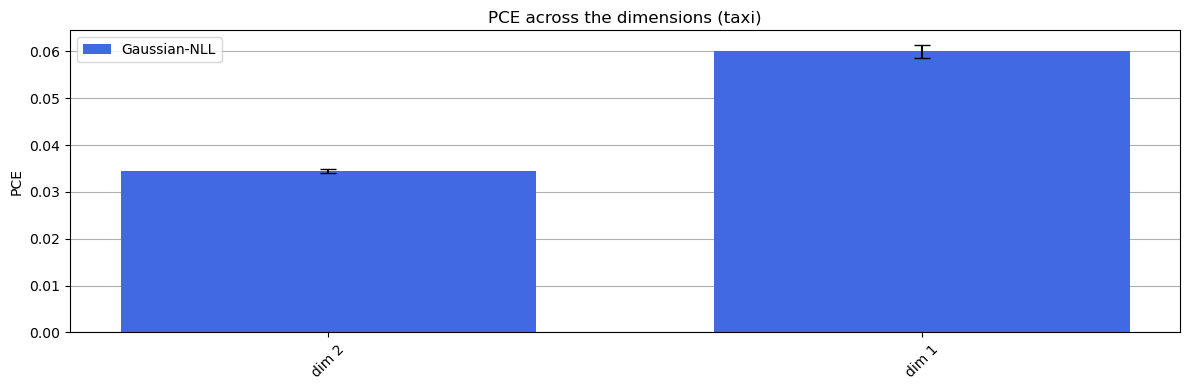

In [43]:
#plotting along PCAs
sorted_indices = np.argsort(average_pce)
sorted_means = [average_pce[i] for i in sorted_indices]
sorted_stderr = [stderr_pce[i] for i in sorted_indices]
sorted_names = [f"dim {i+1}" for i in sorted_indices]
# Step 3: Plot
x = np.arange(len(sorted_names))
#colors: royalblue, darkorange, darkorhcid
plt.figure(figsize=(12, 4))
plt.bar(x, sorted_means, width = 0.7, yerr=sorted_stderr, capsize = 6, 
        color='royalblue', label='Gaussian-NLL', zorder = 2)
plt.xticks(x, sorted_names, rotation=45)
plt.ylabel("PCE")
plt.title("PCE across the dimensions (taxi)")
plt.legend()
plt.grid(True, axis='y', zorder = 1)
plt.tight_layout()
plt.savefig("figures/pce_taxi.png", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
dataset_names = [
    # ['camehl', 'households'],
    #              ['mulan', 'scm20d'],
    #              ['mulan', 'rf2'],
    #              ['mulan', 'rf1'],
    #              ['mulan', 'scm1d'],
    #              ['feldman', 'meps_21'],
    #              ['feldman', 'meps_19'],
    #              ['feldman', 'meps_20'],
    #              ['feldman', 'house'],
    #              ['feldman', 'bio'],
    #              ['feldman', 'blog_data'],
                 ['del_barrio', 'calcofi'],
                 ['wang', 'taxi']
                 ]
seeds = [0, 42, 866, 12, 4]
pces_across_datasets = {}

for dataset in dataset_names:
    data_group, data_name = dataset
    print(f"Working on dataset {data_name}")
    pce_over_seeds = pce_per_dataset(config, data_group, data_name, seeds)
    pces_across_datasets[f'{data_name}'] = np.array(pce_over_seeds)

In [2]:
with open("pce_across_dataset.pkl", "rb") as f:
    pces = pickle.load(f)
with open("pce_calcofi_taxi.pkl", "rb") as f:
    rem_pces = pickle.load(f)

In [8]:
datasets = list(pces.keys())
mean_pces = []
stderr_pces = []
for data in datasets:
    avg = pces[data].mean(axis=0)
    stderr = pces[data].std(axis=0, ddof = 1) / np.sqrt(pces[data].shape[0])
    mean_pces.append(avg)
    stderr_pces.append(stderr)

In [9]:
means = [
    np.array([arr[i] for arr in mean_pces if len(arr) > i])
    for i in range(3)
]
stderrs = [
    np.array([arr[i] for arr in stderr_pces if len(arr) > i])
    for i in range(3)
]

In [18]:
stderrs

[array([0.00276583, 0.00320345, 0.00744775, 0.00755538, 0.00837753,
        0.00353074, 0.00956032, 0.00614453, 0.00113997, 0.00050129,
        0.00063309]),
 array([0.0010815 , 0.00206451, 0.01206009, 0.00737667, 0.00422351,
        0.00421025, 0.00934299, 0.00796526, 0.00074237, 0.00297794,
        0.00090632]),
 array([0.00300147, 0.00073354, 0.00982953, 0.00429497, 0.00547519])]

In [11]:
means

[array([0.01333317, 0.0181701 , 0.05732545, 0.04548757, 0.02902651,
        0.02254424, 0.02727342, 0.0283037 , 0.00891079, 0.00721153,
        0.01447016, 0.00453231, 0.0069237 ]),
 array([0.01202008, 0.01819013, 0.04038795, 0.02709324, 0.02347165,
        0.02722137, 0.03090989, 0.03409117, 0.00995069, 0.01200214,
        0.01775695, 0.00455641, 0.00807783]),
 array([0.01183166, 0.02057567, 0.04046879, 0.04162629, 0.03306437])]

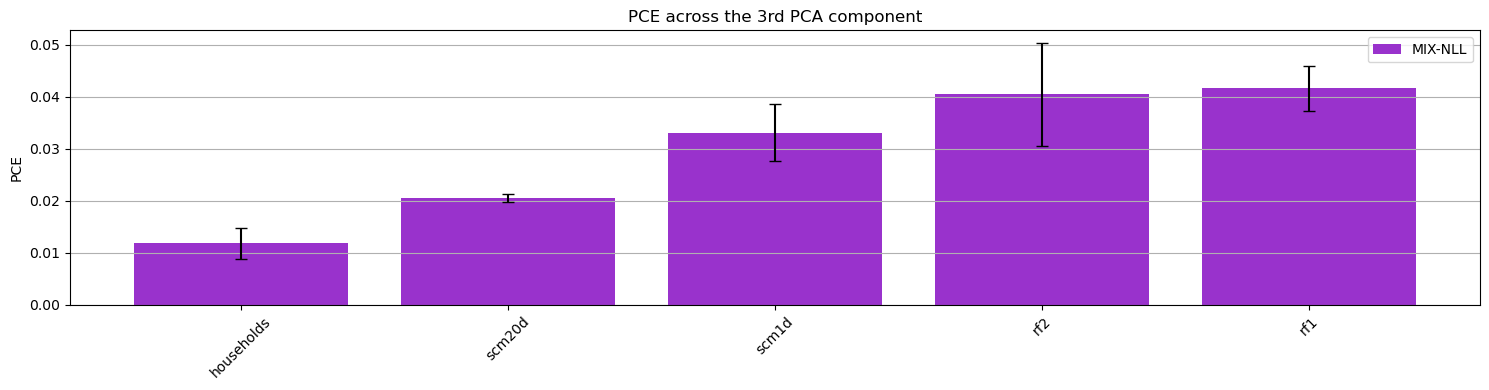

In [16]:
#plotting along PCAs
sorted_indices = np.argsort(means[2])
sorted_names = [datasets[i] for i in sorted_indices]
sorted_means = [means[2][i] for i in sorted_indices]
sorted_stderr = [stderrs[2][i] for i in sorted_indices]

# Step 3: Plot
x = np.arange(len(sorted_names))
#colors: royalblue, darkorange, darkorhcid
plt.figure(figsize=(15, 4))
plt.bar(x, sorted_means, yerr=sorted_stderr, capsize=4, color='darkorchid', label='MIX-NLL')
plt.xticks(x, sorted_names, rotation=45)
plt.ylabel("PCE")
plt.title("PCE across the 3rd PCA component")
plt.legend()
plt.grid(True, axis='y')
plt.tight_layout()
plt.savefig("figures/pce_d3.png", dpi=300, bbox_inches='tight')
plt.show()

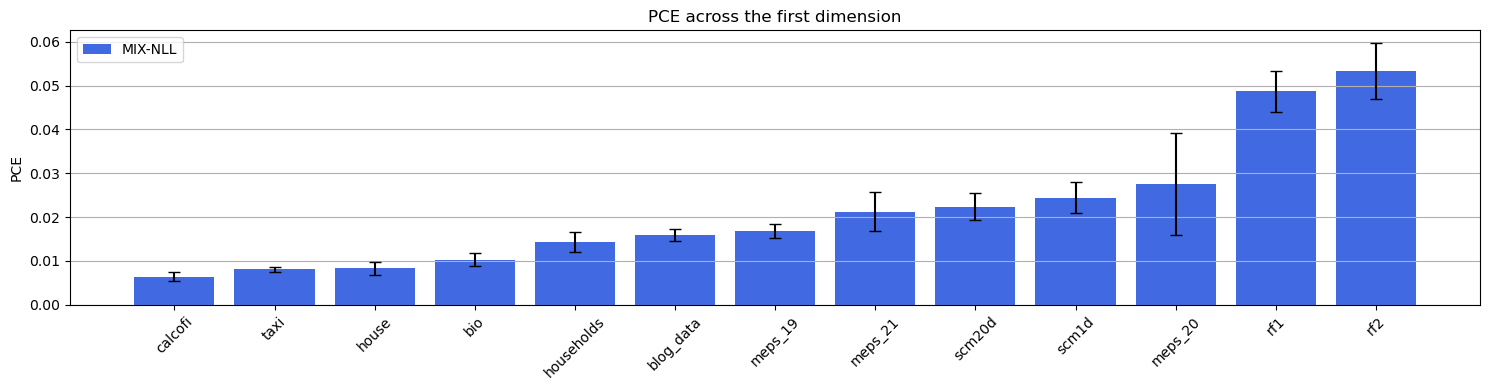

In [ ]:
dataset_names = list(pce_across_datasets.keys())
mean_pces = [np.mean(pce_across_datasets[name]) for name in dataset_names]
stderr_pces = [np.std(pce_across_datasets[name], ddof=1) / np.sqrt(5) for name in dataset_names]

# Step 2: Sort everything by mean PCE


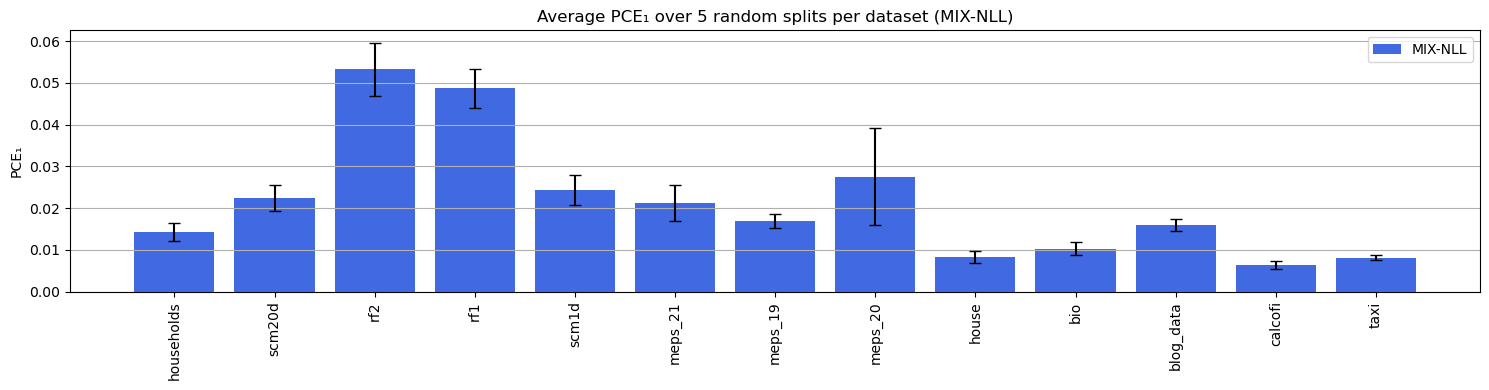

In [ ]:
# Sort dataset names alphabetically (or however you prefer)
dataset_names = pce_across_datasets.keys()

# Compute mean and standard error
mean_pces = [np.mean(pce_across_datasets[name]) for name in dataset_names]
stderr_pces = [np.std(pce_across_datasets[name], ddof=1) / np.sqrt(5) for name in dataset_names]

x = np.arange(len(dataset_names))

plt.figure(figsize=(15, 4))
plt.bar(x, mean_pces, yerr=stderr_pces, capsize=4, color='royalblue', label='MIX-NLL')
# plt.axhline(y=1/12, color='orange', linestyle='--', label='Perfect Calibration (PCE = 1/12)')
plt.xticks(x, dataset_names, rotation=90)
plt.ylabel("PCE")
plt.title("Average PCE over 5 random splits per dataset (MIX-NLL)")
plt.legend()
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()